# PS-S5E12: CatBoost

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**CatBoost** distinguishes itself with its native handling of categorical features, eliminating the need for extensive manual encoding (like One-Hot) often required by other gradient boosting libraries. It utilizes "Ordered Boosting" to combat target leakage and employs symmetric decision trees, which often leads to more robust generalization and faster inference speeds. This model is particularly effective when dealing with datasets containing a mix of numerical physiological markers and categorical demographic data without requiring complex preprocessing.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"
os.environ["MALLOC_ARENA_MAX"] = "2"

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Define some utilities functions
def configure_notebook(seed: int = 10301, float_precision: int = 3, max_columns: int = 15, max_rows: int = 25) -> int:
    """
    Configure notebook settings:
      - Disables warnings for cleaner output.
      - Sets pandas display options for better table formatting.
      - Returns a seed value for reproducibility.
    
    Parameters:
      seed (int): Random seed (default 548).
      float_precision (int): Number of decimal places for floats (default 3).
      max_columns (int): Maximum number of columns to display (default 15).
      max_rows (int): Maximum number of rows to display (default 25).

    Returns:
      int: The provided seed.
    """
    # Disable all warnings
    warnings.filterwarnings('ignore')
    
    # Set pandas display options for nicer output
    pd.options.display.float_format = f'{{:,.{float_precision}f}}'.format
    pd.set_option('display.max_columns', max_columns)
    pd.set_option('display.max_rows', max_rows)

    # Set seeds for reproducibility in numpy and the standard random module
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    return seed

def running_in_kaggle() -> bool:
    """
    Heuristics that are true in Kaggle notebooks:
    - Special directories exist (/kaggle/input, /kaggle/working)
    - Env var KAGGLE_KERNEL_RUN_TYPE is set
    - The kaggle_secrets module is available
    """
    try:
        if os.path.isdir('/kaggle/input') and os.path.isdir('/kaggle/working'):
            return True
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
            return True
        import kaggle_secrets  # noqa: F401  (only exists in Kaggle)
        return True
    except Exception:
        return False

In [3]:
# Apply configuration and set random seeds for reproducibility
seed = configure_notebook(max_columns = None, max_rows = None)

TARGET = 'diagnosed_diabetes'
USE_GPU = False
PERFORM_FEATURE_PRUNING = False
PERFORM_OPTUNA_TUNING = True

## Read and Examine the Training Dataset

In [4]:
DATA_DIR = Path('/kaggle/input/playground-series-s5e12') if running_in_kaggle() else Path('data')

training_df = pd.read_csv(DATA_DIR / 'train.csv')
print(training_df.head(5))

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0               0.930 

## Read and Examine the Test Dataset

In [5]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')
print(test_df.head(5))

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500               

## Feature Engineering

In [6]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'binning',
    'clustering',
    'interactions',
    'ratios',
    'log',
    'polynomials'
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
X.head()

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 43


,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,education_level_ord,income_level_ord,pulse_pressure,mean_arterial_pressure,non_hdl_cholesterol,vai_proxy,lap_proxy,bmi_class,bp_class,age_bmi_interaction,sedentary_ratio,cholesterol_risk_ratio,bp_ratio,whr_bmi_product,triglycerides_log,screen_time_log,age_sq,bmi_sq,cluster_label
0,31,1,45,7.700,6.800,6.100,33.400,0.930,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,2.000,1,42,84.000,141,54.626,"3,168.324",3,0,"1,035.400",0.133,3.431,1.600,31.062,4.635,1.960,961,"1,115.560",4
1,50,2,73,5.700,6.500,5.800,23.800,0.830,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,2.000,3,43,91.333,149,48.990,"2,449.496",1,0,"1,190.000",0.078,3.980,1.558,19.754,4.828,1.917,2500,566.440,5
2,32,3,158,8.500,7.400,9.100,24.100,0.830,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,2.000,1,6,91.000,129,36.616,"2,160.324",1,0,771.200,0.057,3.186,1.067,20.003,4.691,2.313,1024,580.810,1
3,54,3,77,4.600,7.000,9.200,26.600,0.830,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,2.000,1,52,86.333,128,50.289,"2,715.594",2,1,"1,436.400",0.118,3.370,1.754,22.078,4.820,2.322,2916,707.560,5
4,54,1,55,5.700,6.200,5.100,28.800,0.900,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,2.000,3,48,76.000,157,65.593,"3,214.080",2,0,"1,555.200",0.091,4.204,1.800,25.920,4.828,1.808,2916,829.440,4


In [8]:
def get_cat_features(df, cardinality_threshold=10):
    # Start with explicit string/category columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Add integer columns that act as categories
    # Iterate through numerical columns
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    for col in num_cols:
        # If a number has very few unique values, treat it as categorical
        if df[col].nunique() <= cardinality_threshold:
            cat_cols.append(col)
            
    return cat_cols

cat_features = get_cat_features(X)
print(f'Detected Categoricals: {cat_features}')

print('Sanitizing categorical features...')

# Fill NaNs with a generic placeholder (optional, but safer)
# and convert to string to ensure no floats remain.
for col in cat_features:
    # Ensure the column is in the dataframe (sanity check)
    if col in X.columns:
        # Check if it's float or object with mixed types
        # We force it to string. This converts 2.0 -> "2.0" and NaN -> "nan"
        X[col] = X[col].astype(str)
        
        # We must apply the exact same transformation to X_test
        X_test[col] = X_test[col].astype(str)
            
print('Categoricals converted to strings. Floats eliminated.')

Detected Categoricals: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'alcohol_consumption_per_week', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'bmi_class', 'bp_class', 'cluster_label']
Sanitizing categorical features...
Categoricals converted to strings. Floats eliminated.


## Recursive Feature Elimination and Optuna Training

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [9]:
from catboost import CatBoostClassifier, Pool, EShapCalcType, EFeaturesSelectionAlgorithm
from sklearn.model_selection import train_test_split

n_jobs = 1 if USE_GPU else -1

if PERFORM_FEATURE_PRUNING:    
    # Define the model
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        cat_features=cat_features, # Pass your list of names or indices
        verbose=200,
        random_state=seed,
        early_stopping_rounds=50
    )
    
    # CREATE A SPLIT FOR FEATURE SELECTION
    # We need a validation set so CatBoost knows which features generalize well
    X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Create CatBoost Pools (required for feature selection)
    train_pool = Pool(X_fs_train, y_fs_train, cat_features=cat_features)
    val_pool = Pool(X_fs_val, y_fs_val, cat_features=cat_features)   
    
    # Run Native Feature Selection
    summary = model.select_features(
        train_pool,
        eval_set=val_pool,
        features_for_select=train_pool.get_feature_names(), # Pass the list of column names
        num_features_to_select=20,                          # How many features you want to keep
        steps=3,                                            # How many elimination rounds
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,                            # We just want the list, we'll retrain later
        plot=False
    )
    
    # View Selected Features
    # Save the selected features for the next step
    optimal_cols = summary['selected_features_names']
    print('Selected Features:', optimal_cols)
else:
    print('Using all columns as optimal features.')
    optimal_cols = X.columns
    
print('\nOptimal Features:')
print(optimal_cols)

Using all columns as optimal features.

Optimal Features:
Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'education_level_ord', 'income_level_ord',
       'pulse_pressure', 'mean_arterial_pressure', 'non_hdl_cholesterol',
       'vai_proxy', 'lap_proxy', 'bmi_class', 'bp_class',
       'age_bmi_interaction', 'sedentary_ratio', 'cholesterol_risk_ratio',
       'bp_ratio', 'whr_bmi_product', 'triglycerides_log', 'screen_time_log',
       'age_sq', 'bmi_sq', 'cluster_label'],
      dtype='object')


In [10]:
# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]

# Determine the cat_features for the new dataset
cat_features = get_cat_features(X_rfe)
print(f'Detected Categoricals: {cat_features}')

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
def objective(trial):
    # Explicit garbage collection at start of trial
    gc.collect()
    
    # Suggest critical categorical parameters first to control logic flow
    bootstrap_type = trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS'])
    grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])
    
    param = {
        # Core Structure
        'iterations': 6000,              # Equiv to n_estimators

        # STRUCTURAL PARAMS
        # Depthwise/Lossguide often beats SymmetricTree on complex tabular data
        'grow_policy': grow_policy,
        'depth': trial.suggest_int('depth', 4, 10),
    
        # REGULARIZATION
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-1, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-1, 10.0, log=True),
        
        # BOOTSTRAPPING
        # Don't force Bernoulli; let Optuna decide. Bayesian is often better.
        'bootstrap_type': bootstrap_type,
    
        # CATEGORICALS
        # Important: Dictates when to switch to One-Hot vs Target Encoding
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 10),
        
        # GENERAL
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        
        # Boilerplate
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'random_seed': seed,
        'early_stopping_rounds': 50,
        'thread_count': n_jobs,
        'verbose': False,
        'allow_writing_files': False,        # Stop it from spamming drive with log folders
    }

    # Add Conditional Parameters (Only add if supported by the chosen strategy)
    
    # max_leaves is only valid for Lossguide
    if grow_policy == 'Lossguide':
        param['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)
    
    # Bootstrapping logic: subsample vs bagging_temperature
    if bootstrap_type == 'Bayesian':
        param['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0, 10)
    elif bootstrap_type in ['Bernoulli', 'MVS']:
        param['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)

    if param['task_type'] == 'GPU':
        param['metric_period'] = 100
        
    # Fast CV (3 Folds is enough for tuning)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    scores = []
    
    for train_idx, val_idx in skf.split(training_df, y):
        X_train_fold, X_val_fold = training_df.iloc[train_idx], training_df.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Create a FeatureFactory for this fold's data
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)
        
        # Filter Columns using 'optimal_cols'
        # We take the intersection to be safe (in case FE dropped a col for some reason)
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]
        
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

        # Create CatBoost Pools and immediately delete the pandas DataFrames to free RAM
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols)
        val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)

        # Create XGBoost internal DMatrix for efficiency
        # (Optional, but good practice. passing dataframes directly is fine too)
        model = cb.CatBoostClassifier(**param, cat_features=cat_cols)
        
        model.fit(
            train_pool,
            eval_set=[val_pool],
            verbose=False
        )
        
        # Predict
        preds = model.predict_proba(val_pool)[:, 1]
        score = roc_auc_score(y_val_fold, preds)
        scores.append(score)

        return np.mean(scores)

if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='cb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, n_jobs=1, gc_after_trial=True, show_progress_bar=True)

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.06110554763799419,
        'depth': 4,
        'l2_leaf_reg': 0.024445279894910632,
        'random_strength': 1.0029379431588485e-09,
        'subsample': 0.8961703643875382
    }

[I 2025-12-07 19:27:05,464] A new study created in memory with name: cb_diabetes_prediction_optuna


Detected Categoricals: ['alcohol_consumption_per_week', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'bmi_class', 'bp_class', 'cluster_label']


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-07 19:32:08,918] Trial 0 finished with value: 0.7267454973737211 and parameters: {'bootstrap_type': 'MVS', 'grow_policy': 'Lossguide', 'depth': 10, 'l2_leaf_reg': 2.1359821355143342, 'random_strength': 1.061144536416326, 'one_hot_max_size': 6, 'min_data_in_leaf': 60, 'max_leaves': 41, 'subsample': 0.8096385725102344}. Best is trial 0 with value: 0.7267454973737211.
[I 2025-12-07 19:35:33,468] Trial 1 finished with value: 0.7263609958593915 and parameters: {'bootstrap_type': 'MVS', 'grow_policy': 'SymmetricTree', 'depth': 5, 'l2_leaf_reg': 2.3356492555888693, 'random_strength': 0.11721911949764847, 'one_hot_max_size': 7, 'min_data_in_leaf': 90, 'subsample': 0.7862160321198951}. Best is trial 0 with value: 0.7267454973737211.
[I 2025-12-07 19:43:36,258] Trial 2 finished with value: 0.7256698448579374 and parameters: {'bootstrap_type': 'MVS', 'grow_policy': 'SymmetricTree', 'depth': 7, 'l2_leaf_reg': 6.565557611552894, 'random_strength': 2.3089172629719994, 'one_hot_max_size': 

## Model Training

In [11]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 6000,
    'learning_rate': 0.05,
    'depth': 6,
    'eval_metric': 'AUC',
    'random_state': seed,
    'verbose': 200,
}

# Arrays to store results
oof_preds = np.zeros(len(X))     # Out-of-Fold predictions (for blending later)
test_preds = np.zeros(len(test_df)) # Average test predictions

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f'\nStarting CatBoost Training ({n_folds} Folds)...')

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y)):
    X_train_fold, y_train_fold = training_df.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = training_df.iloc[val_idx], y.iloc[val_idx]

    # Create a FeatureFactory for this fold's data
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
        
    # Filter Columns using 'optimal_cols'
    # We take the intersection to be safe (in case FE dropped a col for some reason)
    final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
    
    X_train_trans = X_train_trans[final_cols]
    X_val_trans = X_val_trans[final_cols]
    X_test_trans = X_test_trans[final_cols]

    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = cb.CatBoostClassifier(**cb_tuned_params, cat_features=cat_cols)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_val_trans, y_val_fold)],
        verbose=100,
        early_stopping_rounds=50,
        use_best_model=True
    )
    
    # Predict Validation Set
    # [:, 1] grabs the probability of class 1 (Diabetes)
    val_probs = model.predict_proba(X_val_trans)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Score
    score = roc_auc_score(y_val_fold, val_probs)
    print(f'Fold {fold+1} AUC: {score:.5f} (Best Iteration: {model.get_best_iteration()})')
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(X_test_trans)[:, 1]
    test_preds += test_probs / n_folds

# Evaluation

overall_auc = roc_auc_score(y, oof_preds)
print(f'\nOverall OOF AUC: {overall_auc:.5f}')


Starting CatBoost Training (5 Folds)...
0:	test: 0.6726395	best: 0.6726395 (0)	total: 134ms	remaining: 13m 22s
100:	test: 0.7027007	best: 0.7027007 (100)	total: 14.5s	remaining: 14m 6s
200:	test: 0.7069317	best: 0.7069317 (200)	total: 28.1s	remaining: 13m 31s
300:	test: 0.7133455	best: 0.7133455 (300)	total: 42.6s	remaining: 13m 26s
400:	test: 0.7193442	best: 0.7193442 (400)	total: 57.7s	remaining: 13m 25s
500:	test: 0.7218295	best: 0.7218295 (500)	total: 1m 12s	remaining: 13m 16s
600:	test: 0.7235203	best: 0.7235203 (600)	total: 1m 27s	remaining: 13m 7s
700:	test: 0.7245156	best: 0.7245156 (700)	total: 1m 42s	remaining: 12m 52s
800:	test: 0.7252752	best: 0.7252752 (800)	total: 1m 56s	remaining: 12m 38s
900:	test: 0.7258307	best: 0.7258315 (899)	total: 2m 11s	remaining: 12m 24s
1000:	test: 0.7263231	best: 0.7263231 (1000)	total: 2m 26s	remaining: 12m 9s
1100:	test: 0.7267483	best: 0.7267483 (1100)	total: 2m 40s	remaining: 11m 53s
1200:	test: 0.7269564	best: 0.7269570 (1199)	total: 2m 

## Analyze feature importance

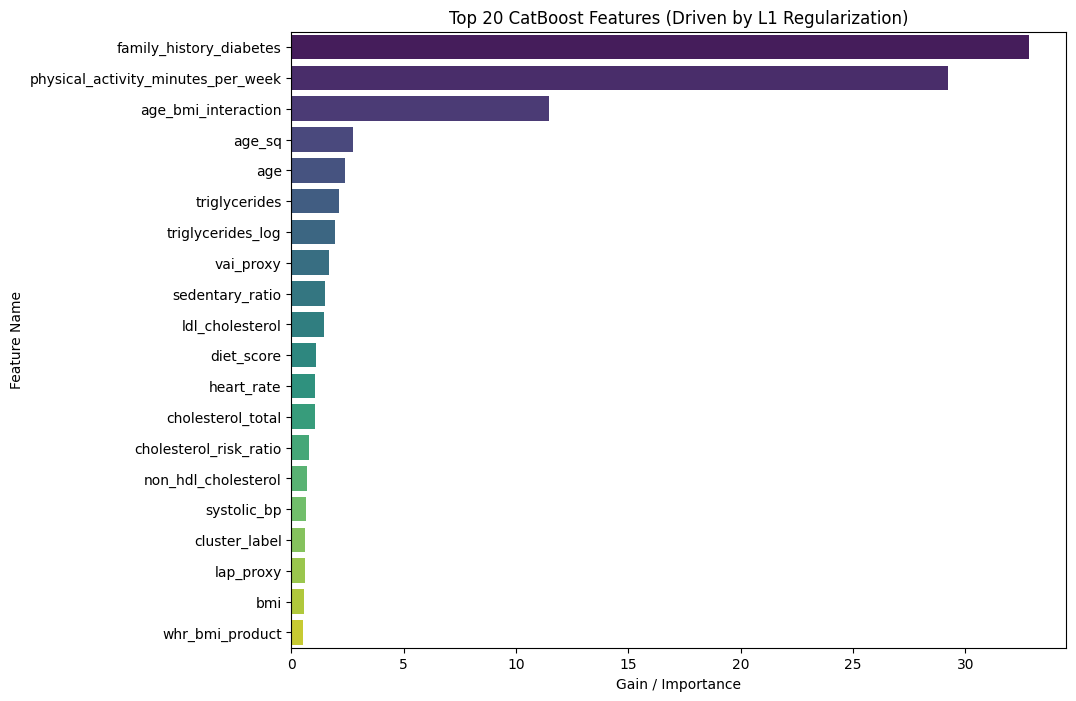

Total Features: 43
Features with > 0 Importance: 43
Features with 0 Importance (Pruned): 0


In [12]:
# Extract Importances
    
# Filter Columns using 'optimal_cols'
# We take the intersection to be safe (in case FE dropped a col for some reason)
final_cols = [c for c in cols_to_keep if c in X_rfe.columns]

X_rfe = X_rfe[final_cols]

# 'model' is the trained XGBoost classifier from the last fold of your loop
importance = model.feature_importances_
feature_names = X_rfe.columns

# Create a DataFrame & Sort
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot Top 20 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(20), palette='viridis')
plt.title('Top 20 CatBoost Features (Driven by L1 Regularization)')
plt.xlabel('Gain / Importance')
plt.ylabel('Feature Name')
plt.show()

# Analyze "Dead" Features
zero_imp_features = fi_df[fi_df['Importance'] == 0]
print(f'Total Features: {len(fi_df)}')
print(f'Features with > 0 Importance: {len(fi_df) - len(zero_imp_features)}')
print(f'Features with 0 Importance (Pruned): {len(zero_imp_features)}')

if len(zero_imp_features) > 0:
    print('\nExamples of Pruned Features:')
    print(zero_imp_features['Feature'].head(10).tolist())

## Prepare Submission

In [13]:
submission_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')
submission_df[TARGET] = test_preds
submission_df.head(10)

,id,diagnosed_diabetes
0,700000,0.479
1,700001,0.689
2,700002,0.781
3,700003,0.410
4,700004,0.931
5,700005,0.638
6,700006,0.729
7,700007,0.933
8,700008,0.562
9,700009,0.861


In [14]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

In [15]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_cb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/cb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_cb': test_preds})
test_pred_df.to_csv(f'{output_dir}/cb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/cb_oof_preds.csv, {output_dir}/cb_test_preds.csv')

Saved for Blending: predictions/cb_oof_preds.csv, predictions/cb_test_preds.csv
